In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModel,
    get_linear_schedule_with_warmup
)
# Импортируем AdamW из torch.optim, так как в новых версиях transformers он перемещён
from torch.optim import AdamW
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков для отображения в ноутбуке
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [29]:
class Config:
    MODEL_NAME = "sentence-transformers/LaBSE"
    MAX_LEN = 128
    BATCH_SIZE = 16
    EPOCHS = 10
    LEARNING_RATE = 2e-5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
print(f"🔧 Используем устройство: {Config.DEVICE}")
print(f"📊 Параметры: MAX_LEN={Config.MAX_LEN}, BATCH_SIZE={Config.BATCH_SIZE}, EPOCHS={Config.EPOCHS}")

🔧 Используем устройство: cuda
📊 Параметры: MAX_LEN=128, BATCH_SIZE=16, EPOCHS=10


In [30]:
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Используем современный метод токенизации (вместо encode_plus)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [31]:
class IntentClassifier(nn.Module):
    def __init__(self, n_classes, model_name=Config.MODEL_NAME):
        super(IntentClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(p=0.4)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Используем [CLS] токен для классификации
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

In [32]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

def eval_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            _, preds = torch.max(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, all_preds, all_labels

In [33]:
def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График потерь
    axes[0].plot(train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
    axes[0].plot(val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=6)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # График точности
    axes[1].plot(train_accs, 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
    axes[1].plot(val_accs, 'r-o', label='Validation Accuracy', linewidth=2, markersize=6)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(14, 12))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_metrics_bar(precision, recall, f1, class_names):
    """Bar plot для precision, recall, f1 по каждому классу"""
    x = np.arange(len(class_names))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
    ax.bar(x, recall, width, label='Recall', alpha=0.8)
    ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)
    
    ax.set_xlabel('Intent Classes', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Precision, Recall, and F1-Score by Class', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()

def plot_class_distribution(y_train, y_val, class_names):
    """Распределение классов в train и val"""
    train_counts = np.bincount(y_train, minlength=len(class_names))
    val_counts = np.bincount(y_val, minlength=len(class_names))
    
    x = np.arange(len(class_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.bar(x - width/2, train_counts, width, label='Train', alpha=0.8)
    ax.bar(x + width/2, val_counts, width, label='Validation', alpha=0.8)
    
    ax.set_xlabel('Intent Classes', fontsize=12)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_title('Class Distribution in Train and Validation Sets', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

In [34]:
# 1. Загрузка датасета
print("=" * 70)
print("🚀 ДООБУЧЕНИЕ МОДЕЛИ ДЛЯ КЛАССИФИКАЦИИ ИНТЕНЦИЙ")
print("=" * 70)

print("\n📂 Загрузка датасета...")
df = pd.read_csv('/kaggle/input/datasets/yuliaush/combined/combined_intent_dataset.csv', encoding='utf-8-sig')
print(f"   Загружено {len(df)} запросов")
print(f"   Колонки: {df.columns.tolist()}")

# Определяем колонки
X = df['user_query'].values
# Кодируем метки
if 'intent' in df.columns:
    le = LabelEncoder()
    y = le.fit_transform(df['intent'])
    intent_names = le.classes_
elif 'intent_id' in df.columns:
    y = df['intent_id'].values
    intent_names = [f"class_{i}" for i in range(y.max() + 1)]
else:
    raise ValueError("Не найдена колонка 'intent' или 'intent_id'")

print(f"   Количество классов: {len(intent_names)}")
print(f"   Классы: {list(intent_names)}")

🚀 ДООБУЧЕНИЕ МОДЕЛИ ДЛЯ КЛАССИФИКАЦИИ ИНТЕНЦИЙ

📂 Загрузка датасета...
   Загружено 5203 запросов
   Колонки: ['user_query', 'intent', 'intent_id']
   Количество классов: 18
   Классы: ['active_sport', 'budget_leisure', 'cafe_dessert', 'cultural', 'evening_night', 'first_date', 'food_search', 'gaming', 'general_recommendation', 'luxury_premium', 'outdoor_walk', 'party_nightclub', 'quiet_cozy', 'relax_wellness', 'romantic_date', 'view_scenic', 'with_family', 'with_friends']



📊 Разделение данных:
   Train: 4162 samples
   Validation: 1041 samples


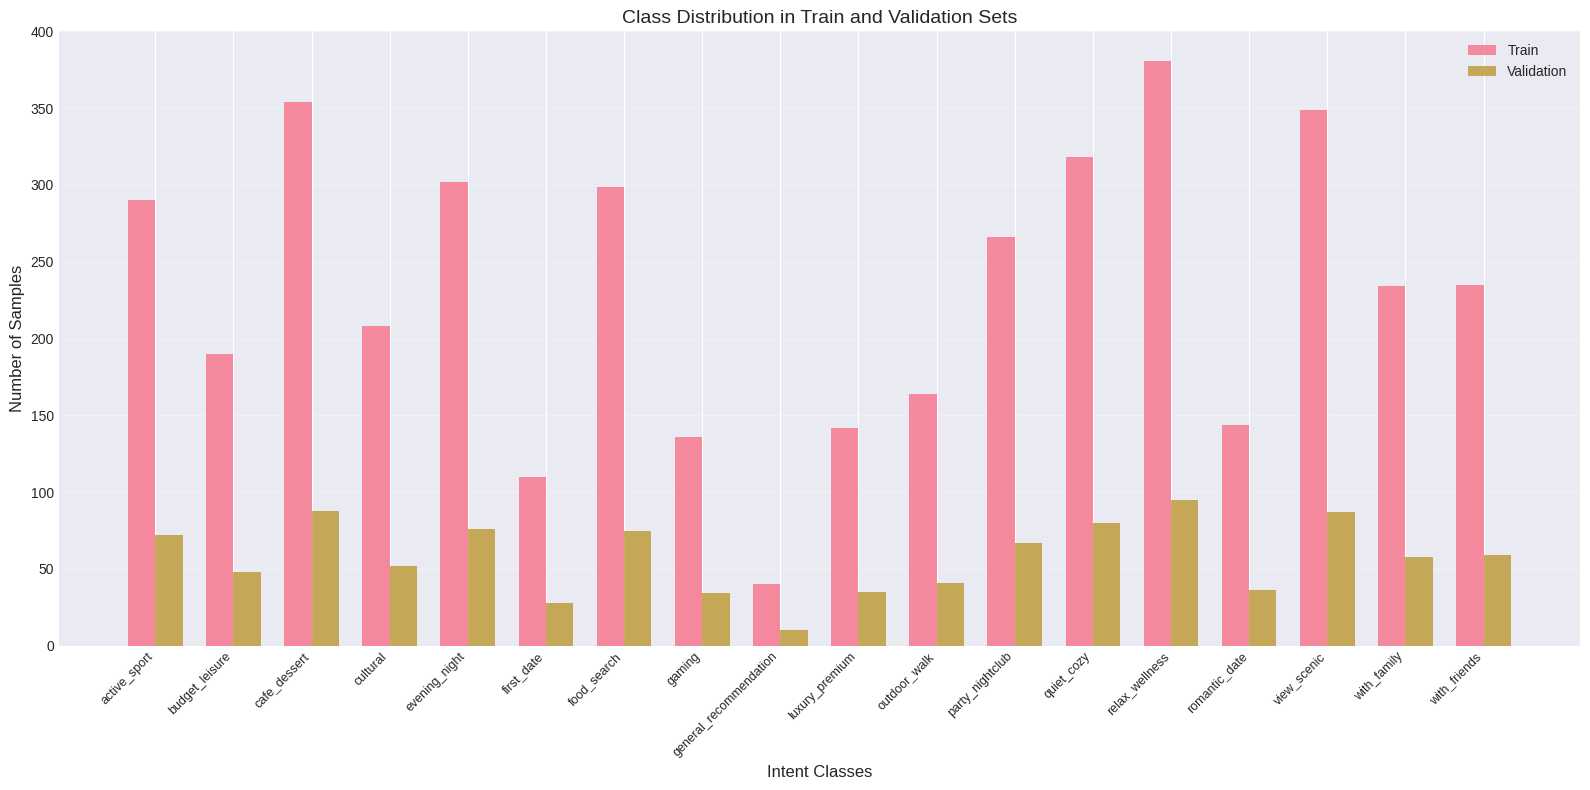

In [35]:
# 2. Разделение на train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n📊 Разделение данных:")
print(f"   Train: {len(X_train)} samples")
print(f"   Validation: {len(X_val)} samples")

# Визуализация распределения классов
plot_class_distribution(y_train, y_val, intent_names)

In [36]:
# 3. Инициализация токенизатора и датасетов
print(f"\n🔧 Инициализация модели {Config.MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)

train_dataset = IntentDataset(X_train, y_train, tokenizer, Config.MAX_LEN)
val_dataset = IntentDataset(X_val, y_val, tokenizer, Config.MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")


🔧 Инициализация модели sentence-transformers/LaBSE...
   Train batches: 261
   Val batches: 66


In [37]:
# 4. Инициализация модели
model = IntentClassifier(n_classes=len(intent_names)).to(Config.DEVICE)
print(f"   Модель загружена на {Config.DEVICE}")

# Подсчёт параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Всего параметров: {total_params:,}")
print(f"   Обучаемых параметров: {trainable_params:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Модель загружена на cuda
   Всего параметров: 470,940,690
   Обучаемых параметров: 470,940,690


In [38]:
# 5. Оптимизатор и scheduler
optimizer = AdamW(model.parameters(), lr=Config.LEARNING_RATE)#, weight_decay=0.01)
total_steps = len(train_loader) * Config.EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss()

In [39]:
# 6. Обучение
print(f"\n🎓 Начало обучения на {Config.EPOCHS} эпохах...")
print(f"   Устройство: {Config.DEVICE}")
print("   " + "-" * 50)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

for epoch in range(Config.EPOCHS):
    print(f"\n📈 Epoch {epoch+1}/{Config.EPOCHS}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, Config.DEVICE)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validation
    val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, Config.DEVICE)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_intent_model.pt')
        print(f"   Лучшая модель сохранена (acc={val_acc:.4f})")


🎓 Начало обучения на 10 эпохах...
   Устройство: cuda
   --------------------------------------------------

📈 Epoch 1/10


Validation: 100%|██████████| 66/66 [00:07<00:00,  8.29it/s]


   Train Loss: 2.1588 | Train Acc: 0.3462
   Val Loss: 0.7642 | Val Acc: 0.7666
   Лучшая модель сохранена (acc=0.7666)

📈 Epoch 2/10


Validation: 100%|██████████| 66/66 [00:08<00:00,  7.71it/s]


   Train Loss: 0.6255 | Train Acc: 0.8111
   Val Loss: 0.5914 | Val Acc: 0.8213
   Лучшая модель сохранена (acc=0.8213)

📈 Epoch 3/10


...

   Train Loss: 0.0244 | Train Acc: 0.9933
   Val Loss: 0.7064 | Val Acc: 0.8770
   Лучшая модель сохранена (acc=0.8770)

📈 Epoch 9/10


Validation: 100%|██████████| 66/66 [00:08<00:00,  7.50it/s]


   Train Loss: 0.0139 | Train Acc: 0.9962
   Val Loss: 0.7027 | Val Acc: 0.8665

📈 Epoch 10/10


Validation: 100%|██████████| 66/66 [00:08<00:00,  7.51it/s]

   Train Loss: 0.0084 | Train Acc: 0.9983
   Val Loss: 0.7175 | Val Acc: 0.8655


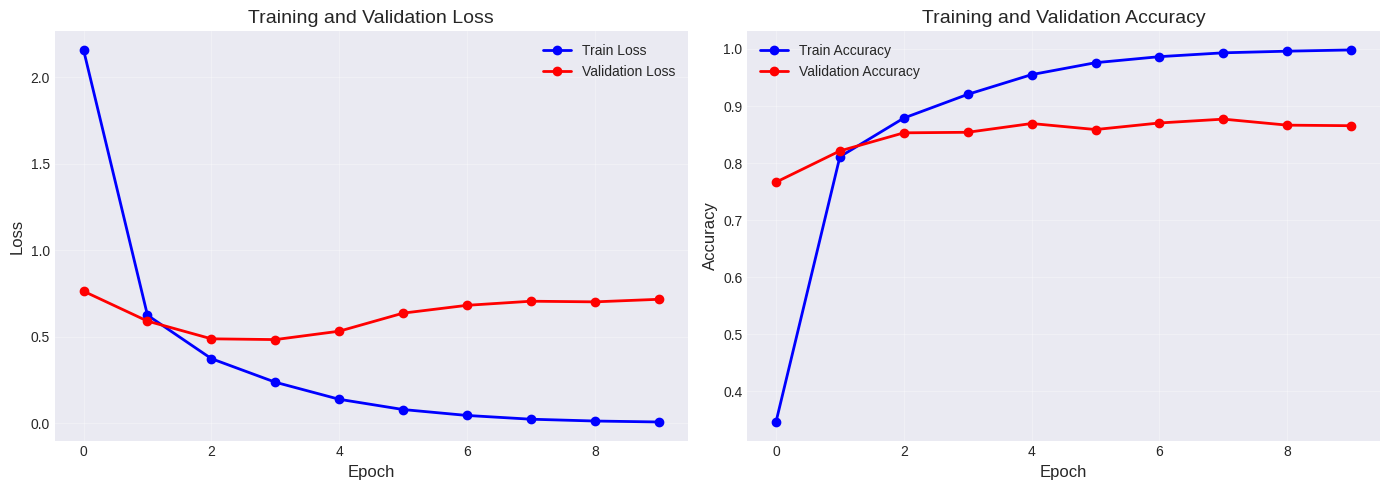

In [40]:
# 7. Визуализация обучения
plot_training_history(train_losses, val_losses, train_accs, val_accs)

In [41]:
print("\n" + "=" * 70)
print("📊 ФИНАЛЬНЫЕ МЕТРИКИ")
print("=" * 70)

accuracy = accuracy_score(val_labels, val_preds)
precision = precision_score(val_labels, val_preds, average='weighted')
recall = recall_score(val_labels, val_preds, average='weighted')
f1 = f1_score(val_labels, val_preds, average='weighted')

print(f"\n🎯 Общие метрики (weighted average):")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")


📊 ФИНАЛЬНЫЕ МЕТРИКИ

🎯 Общие метрики (weighted average):
   Accuracy:  0.8655
   Precision: 0.8664
   Recall:    0.8655
   F1-Score:  0.8641


In [42]:
print(f"\n📋 Детальный отчет по каждому классу:")
report = classification_report(val_labels, val_preds, target_names=intent_names, digits=4)
print(report)


📋 Детальный отчет по каждому классу:
                        precision    recall  f1-score   support

          active_sport     0.7746    0.7639    0.7692        72
        budget_leisure     0.9000    0.7500    0.8182        48
          cafe_dessert     0.9255    0.9886    0.9560        88
              cultural     0.9091    0.9615    0.9346        52
         evening_night     0.8750    0.8289    0.8514        76
            first_date     0.8000    0.8571    0.8276        28
           food_search     0.9254    0.8267    0.8732        75
                gaming     0.9714    1.0000    0.9855        34
general_recommendation     0.7273    0.8000    0.7619        10
        luxury_premium     0.9000    0.7714    0.8308        35
          outdoor_walk     0.7857    0.8049    0.7952        41
       party_nightclub     0.8533    0.9552    0.9014        67
            quiet_cozy     0.8714    0.7625    0.8133        80
        relax_wellness     0.8990    0.9368    0.9175        95
 

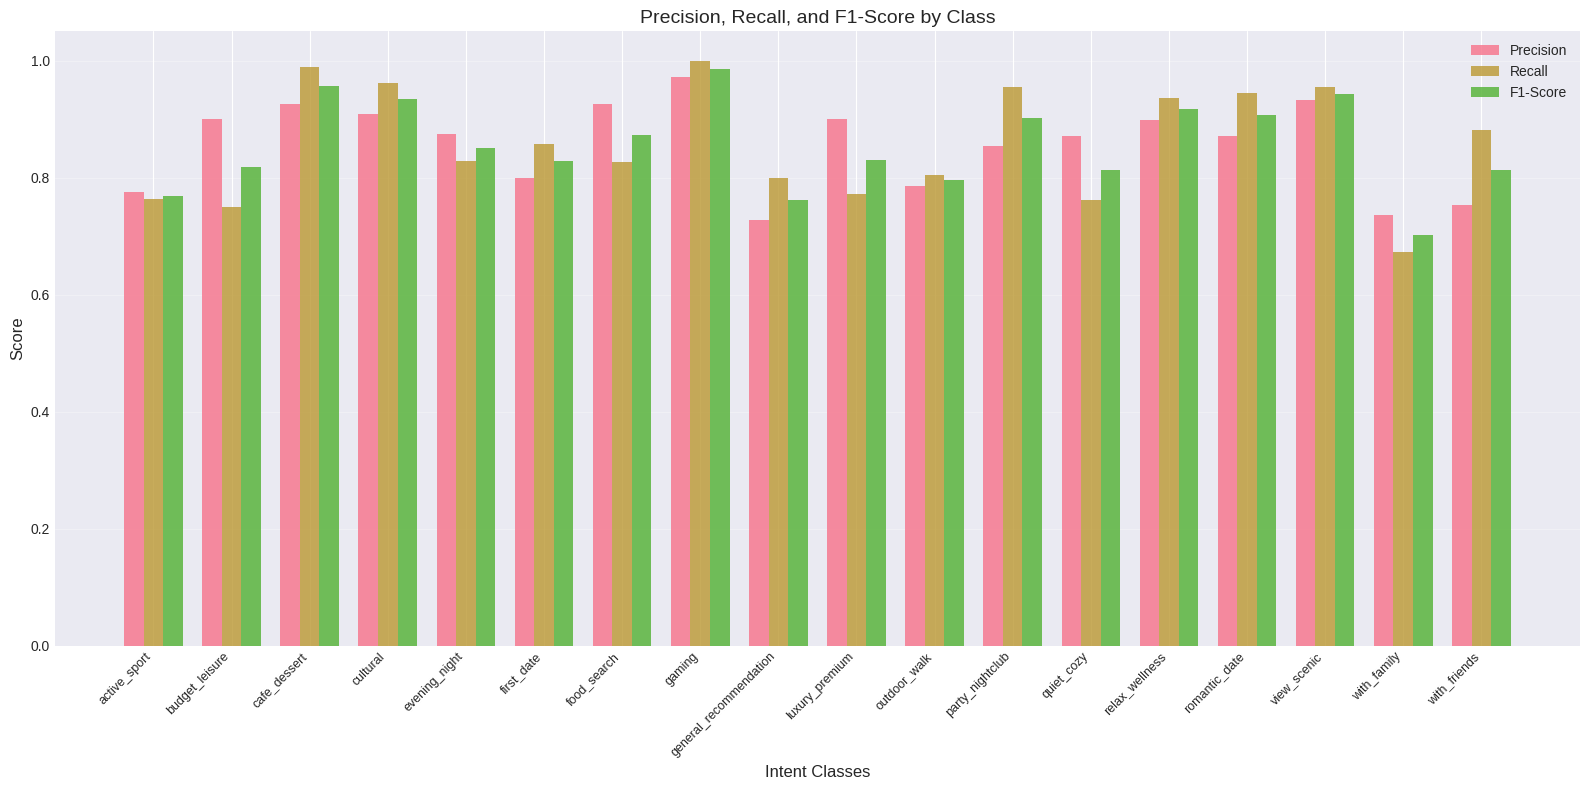

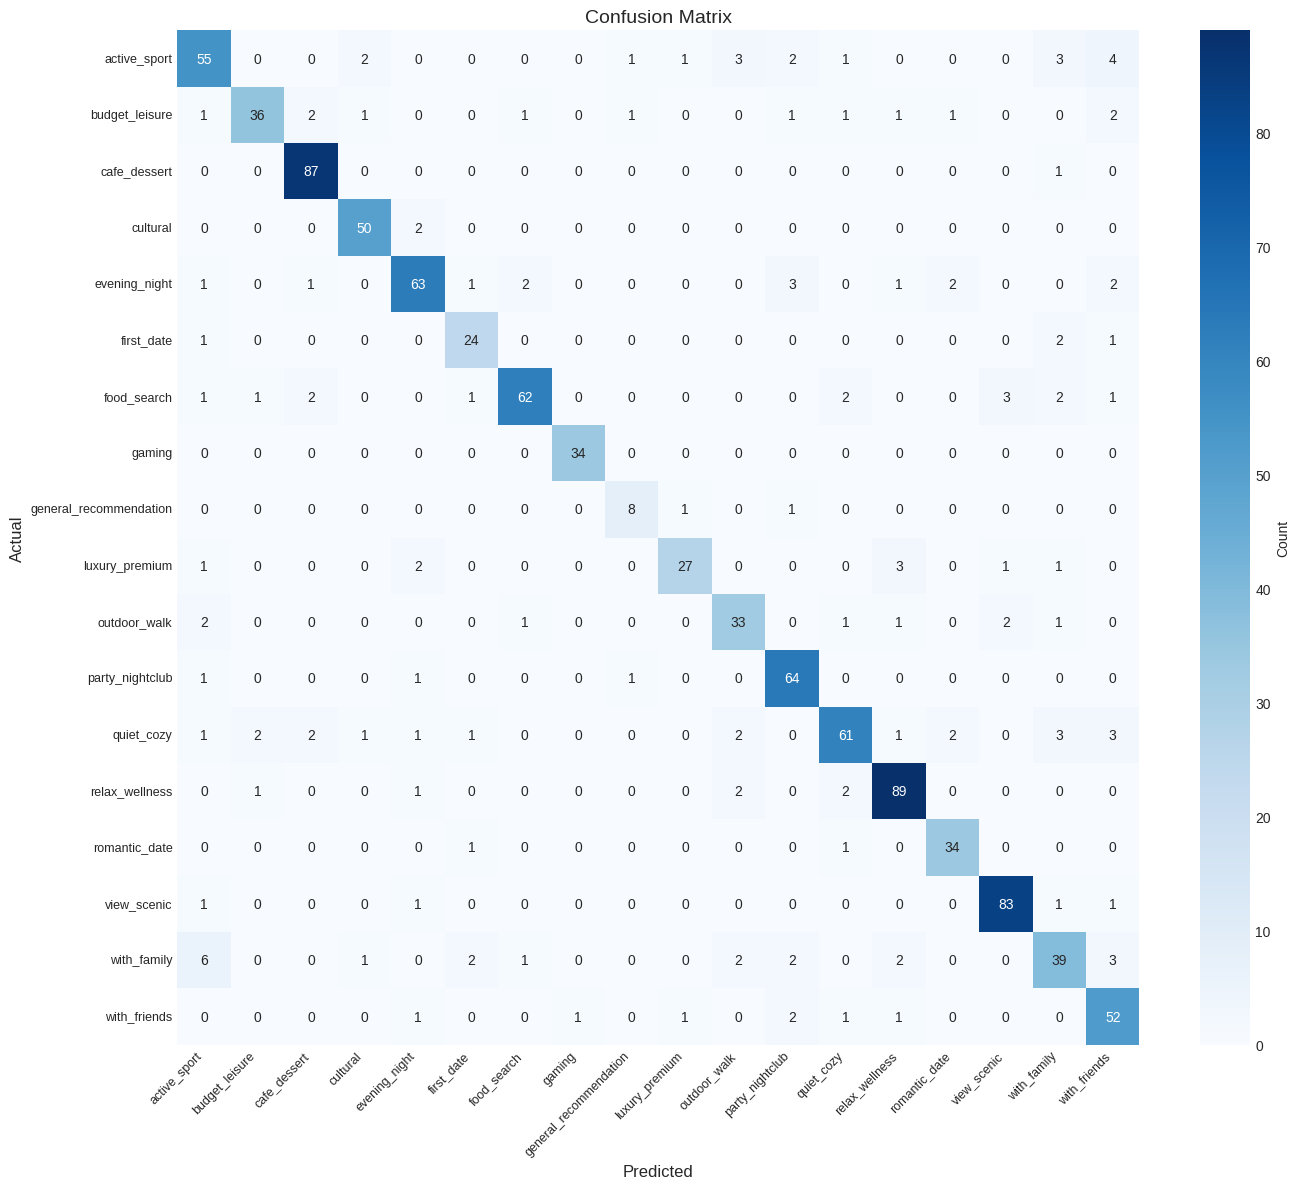

In [43]:
precision_per_class = precision_score(val_labels, val_preds, average=None)
recall_per_class = recall_score(val_labels, val_preds, average=None)
f1_per_class = f1_score(val_labels, val_preds, average=None)

plot_metrics_bar(precision_per_class, recall_per_class, f1_per_class, intent_names)

# %%
# Матрица ошибок
plot_confusion_matrix(val_labels, val_preds, intent_names)


In [44]:
def predict_intent(query, model, tokenizer, le, device, max_len=128):
    model.eval()
    
    encoding = tokenizer(
        query,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        probabilities = torch.softmax(outputs, dim=1)
        pred_class_id = torch.argmax(probabilities, dim=1).item()
        confidence = torch.max(probabilities).item()
    
    intent_name = le.inverse_transform([pred_class_id])[0]
    
    return {
        'query': query,
        'intent': intent_name,
        'confidence': confidence
    }

# Тестовые запросы
test_queries = [
    "Где вкусно и недорого поесть в центре?",
    "привет!Хочу устроить романтический ужин с девушкой, у нас уже пятое свидание, я хочу произвести впечатление",
    "Куда сходить с ребёнком 8 лет? чтоб была парковка, вайфай, а еще мне нужно поработать",
    "Посоветуйте тихое место с ноутбуком поработать",
    "Где можно оторваться на выходных?",
    "Хочу с подругой подготивиться к экзаменам, попить кофу",
    "привет! у меня очень хорошее настроение я хочу гулять, веселиться и можно пообедать"
]

print("\n" + "=" * 70)
print("🧪 ТЕСТИРОВАНИЕ НА НОВЫХ ПРИМЕРАХ")
print("=" * 70)

for query in test_queries:
    result = predict_intent(query, model, tokenizer, le, Config.DEVICE, Config.MAX_LEN)
    print(f"\n📝 Запрос: \"{result['query']}\"")
    print(f"🎯 Предсказанная интенция: {result['intent']}")
    print(f"📊 Уверенность: {result['confidence']:.2%}")


🧪 ТЕСТИРОВАНИЕ НА НОВЫХ ПРИМЕРАХ

📝 Запрос: "Где вкусно и недорого поесть в центре?"
🎯 Предсказанная интенция: food_search
📊 Уверенность: 99.76%

📝 Запрос: "привет!Хочу устроить романтический ужин с девушкой, у нас уже пятое свидание, я хочу произвести впечатление"
🎯 Предсказанная интенция: first_date
📊 Уверенность: 99.95%

📝 Запрос: "Куда сходить с ребёнком 8 лет? чтоб была парковка, вайфай, а еще мне нужно поработать"
🎯 Предсказанная интенция: with_family
📊 Уверенность: 99.77%

📝 Запрос: "Посоветуйте тихое место с ноутбуком поработать"
🎯 Предсказанная интенция: quiet_cozy
📊 Уверенность: 69.44%

📝 Запрос: "Где можно оторваться на выходных?"
🎯 Предсказанная интенция: evening_night
📊 Уверенность: 50.81%

📝 Запрос: "Хочу с подругой подготивиться к экзаменам, попить кофу"
🎯 Предсказанная интенция: with_friends
📊 Уверенность: 98.72%

📝 Запрос: "привет! у меня очень хорошее настроение я хочу гулять, веселиться и можно пообедать"
🎯 Предсказанная интенция: outdoor_walk
📊 Уверенность: 92.63%


In [45]:
from IPython.display import FileLink

# Если файл находится в рабочей директории '/kaggle/working/'
FileLink('best_intent_model.pt')

/kaggle/working/best_intent_model.pt